# 04 · Ultrametric ML: digits, dendrogram, p-adic kNN

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mircus/padics/blob/master/notebooks/04_ultrametric_ml.ipynb)

End-to-end ML pipeline using p-adic distances: hierarchical clustering and k-nearest-neighbours classification in Q_p.

In [1]:
# Install padic-ds (skip if already installed)
import importlib, subprocess, sys
if importlib.util.find_spec('padic') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'git+https://github.com/Mircus/padics.git'])


In [2]:
from padic import QpContext, Qp, ultrametric_dendrogram, PadicKNNClassifier, pairwise_padic_dist
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
print('Libraries loaded ✓')


Libraries loaded ✓


## Ultrametric dendrogram

In [3]:
ctx = QpContext(3, prec=6)
nums = [1, 4, 10, 13, 40, 121]
X = [Qp.from_int(ctx, n) for n in nums]

D = pairwise_padic_dist(X)
print('Pairwise 3-adic distance matrix:')
print(np.round(D, 4))


Pairwise 3-adic distance matrix:
[[0.     0.3333 0.1111 0.3333 0.3333 0.3333]
 [0.3333 0.     0.3333 0.1111 0.1111 0.1111]
 [0.1111 0.3333 0.     0.3333 0.3333 0.3333]
 [0.3333 0.1111 0.3333 0.     0.037  0.037 ]
 [0.3333 0.1111 0.3333 0.037  0.     0.0123]
 [0.3333 0.1111 0.3333 0.037  0.0123 0.    ]]


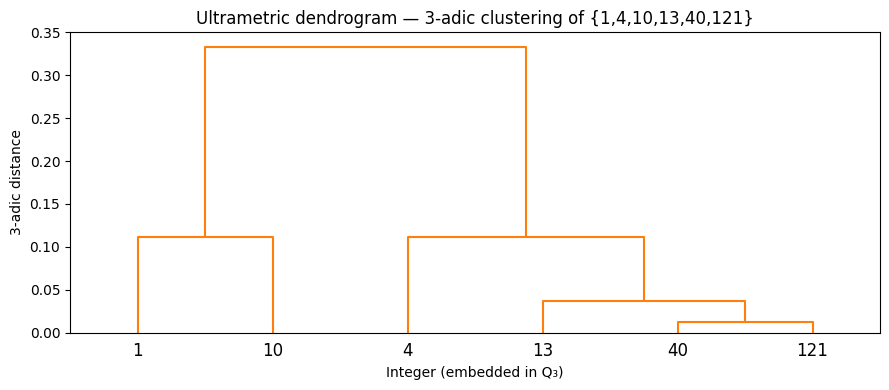

Integers sharing 3-adic digits cluster together.


In [4]:
condensed = squareform(D)
Z = linkage(condensed, method='complete')

fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(Z, labels=[str(n) for n in nums], ax=ax, color_threshold=0.35)
ax.set_title('Ultrametric dendrogram — 3-adic clustering of {1,4,10,13,40,121}', fontsize=12)
ax.set_xlabel('Integer (embedded in Q₃)')
ax.set_ylabel('3-adic distance')
plt.tight_layout()
plt.savefig('ultrametric_dendro.png', dpi=120, bbox_inches='tight')
plt.show()
print('Integers sharing 3-adic digits cluster together.')


## Distance matrix heatmap

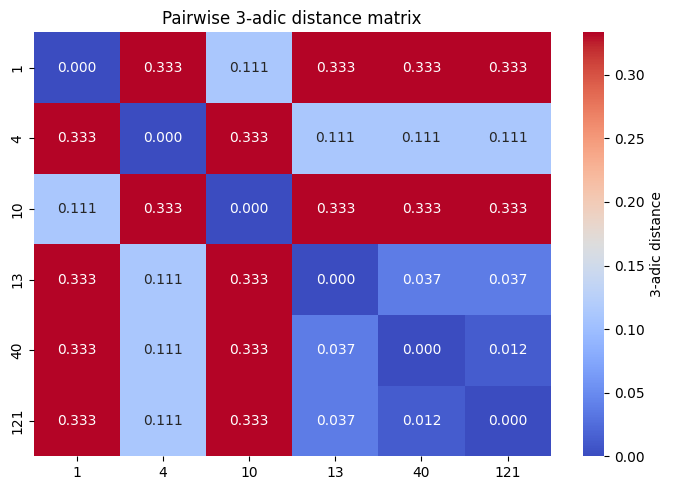

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(D, annot=True, fmt='.3f',
            xticklabels=nums, yticklabels=nums,
            cmap='coolwarm', ax=ax,
            cbar_kws={'label': '3-adic distance'})
ax.set_title('Pairwise 3-adic distance matrix', fontsize=12)
plt.tight_layout()
plt.savefig('dist_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


## p-adic kNN classifier

In [6]:
def embed_row(row, ctx):
    return [Qp.from_rational(ctx, int(round(100*r)), 1) for r in row]

np.random.seed(0)
Xr = np.array([[0.10,0.20],[0.11,0.21],[0.12,0.19],[2.00,2.00],[2.01,2.02],[1.99,2.03]])
yr = np.array([0,0,0,1,1,1])
Xq = [embed_row(row, ctx) for row in Xr]
clf = PadicKNNClassifier(ctx, k=1).fit(Xq, yr)
y_pred = clf.predict(Xq)
acc = (y_pred == yr).mean()
print('True labels:     ', yr.tolist())
print('Predicted labels:', y_pred.tolist())
print(f'Accuracy: {acc:.1%}')


True labels:      [0, 0, 0, 1, 1, 1]
Predicted labels: [0, 0, 0, 1, 1, 1]
Accuracy: 100.0%


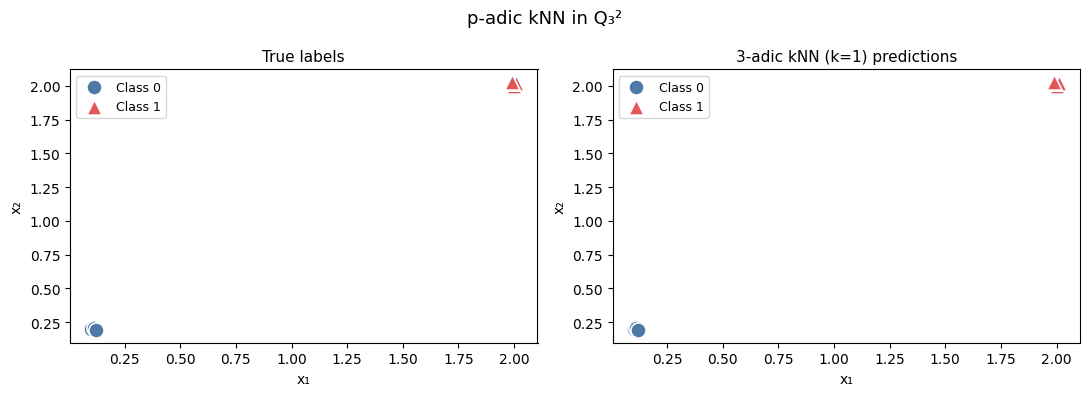

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (y_plot, title) in zip(axes,
        [(yr, 'True labels'), (y_pred, '3-adic kNN (k=1) predictions')]):
    ax.scatter(Xr[y_plot==0,0], Xr[y_plot==0,1], c='#4e79a7', s=120,
               label='Class 0', zorder=3, edgecolors='white', lw=1.2)
    ax.scatter(Xr[y_plot==1,0], Xr[y_plot==1,1], c='#e15759', marker='^', s=120,
               label='Class 1', zorder=3, edgecolors='white', lw=1.2)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
plt.suptitle('p-adic kNN in Q₃²', fontsize=13)
plt.tight_layout()
plt.savefig('knn_classification.png', dpi=120, bbox_inches='tight')
plt.show()


> **Library limitation:** embeddings are finite-precision ($\leq$ `ctx.prec` base-p digits). Very large integers or tiny rationals may incur precision loss. Always verify with `padic_dist` that embedded points have the expected distances.

See the full [tutorial notebook](00_tutorial.ipynb) for a complete tour.